## 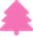XGBoost TRaining using spaCy

Testing not to use

In [1]:
# Necessary libraries for the full process (preprocessing, vectorization, training, evaluation)
import os 
import pandas as pd
import spacy # Essential for NLP preprocessing
import re # Essential for URL/special character removal
from xgboost import XGBClassifier # For the final model training
from sklearn.model_selection import train_test_split # For splitting data
from sklearn.metrics import f1_score # For evaluating the model
from sklearn.feature_extraction.text import TfidfVectorizer # Kept for potential use
from sklearn.decomposition import TruncatedSVD # Kept for potential use (Dimensionality Reduction)

RND = 42 # Random state for reproducibility

In [2]:
# Load the expanded dataset
DATA_PATH = '../resources/dataset/synonym_youtoxic_english_1000.csv'
assert os.path.exists(DATA_PATH), f"Data file not found: {DATA_PATH}"
df = pd.read_csv(DATA_PATH)
print('Loaded', DATA_PATH, 'shape=', df.shape)
df.head()

Loaded ../resources/dataset/synonym_youtoxic_english_1000.csv shape= (3751, 16)


,Unnamed: 0,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
0,0,Ugg2KwwX0V8-aXgCoAEC,04kJtp6pVXI,If only people would just take a step back and...,False,False,False,False,False,False,False,False,False,False,False,False
1,1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to app...,True,True,False,False,False,False,False,False,False,False,False,False
2,1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement embody not train to shoot to a...,True,True,False,False,False,False,False,False,False,False,False,False
3,1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement make up not trained to shoot t...,True,True,False,False,False,False,False,False,False,False,False,False
4,1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Legal philosophy enforcement is not trained to...,True,True,False,False,False,False,False,False,False,False,False,False


In [3]:
# Identify label columns (common names used in the original notebook)
target_cols = [
    'IsToxic', 'IsAbusive', 'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist'
]
# Keep only the labels that are present in the dataset
present_targets = [c for c in target_cols if c in df.columns]
if len(present_targets) == 0:
    raise ValueError("No expected target columns found in the uploaded CSV. Please ensure the file contains at least one of: " + ','.join(target_cols))
print('Using target columns:', present_targets)

Using target columns: ['IsToxic', 'IsAbusive', 'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist']


In [4]:
# Safe text column detection
text_col = None
for candidate in ['text','Text','comment_text','comment','commentText']:
    if candidate in df.columns:
        text_col = candidate
        break
if text_col is None:
    raise ValueError("No text column found in data (expected one of: text, Text, comment_text, comment, commentText).")
print('Using text column:', text_col)
df[text_col] = df[text_col].astype(str)

Using text column: Text


## **📚 Standard Text Cleaning with spaCy for Classification**

The goal of standard text cleaning is to transform raw, noisy text into a structured, simplified format (**Noise Reduction**), which leads to a smaller, more meaningful vocabulary (**Dimensionality Reduction, Memory Efficiency**), and ultimately helps your model generalize better (**Reduce Overfitting**).

### **Step 1: Initialization and Setup**

First, you need to import the necessary libraries and load the spaCy model. We use the small model and carefully disable components we don't need for the core *cleaning* pipeline, making it fast.

Python 

In [11]:
# Basic imports
import os
import pandas as pd
import spacy
import re

RND = 42

# 1. Load the small English model and disable non-essential components for speed
# 'tagger' and 'lemmatizer' are essential for accurate lemmatization and filtering.
try:
    nlp = spacy.load("en_core_web_sm", disable=["parser", "ner", "textcat"])
except OSError:
    print("Error: spaCy model 'en_core_web_sm' not found. Please run: python -m spacy download en_core_web_sm")
    raise

# Get the default set of spaCy stop words (although token.is_stop is used below)
STOP_WORDS = spacy.lang.en.stop_words.STOP_WORDS

# Load the expanded dataset
DATA_PATH = '../resources/dataset/synonym_youtoxic_english_1000.csv'
assert os.path.exists(DATA_PATH), f"Data file not found: {DATA_PATH}"
df = pd.read_csv(DATA_PATH)
print('Loaded', DATA_PATH, 'shape=', df.shape)

# Identify the text column (based on your previous output)
text_col = 'Text'
df[text_col] = df[text_col].astype(str)
print(f'Using text column: {text_col}')

Loaded ../resources/dataset/synonym_youtoxic_english_1000.csv shape= (3751, 16)
Using text column: Text


### **Step 2: The Combined Preprocessing Function**

The most efficient way to process text with spaCy is to combine the cleaning steps (using Python's re) and the linguistic steps (using spaCy) into one function.

Here is the function, with each of your learning points mapped to a specific action:

2. The spaCy Preprocessing Function
This is the exact cleaning function we defined previously, ready to be applied.

In [ ]:
def clean_and_tokenize_spacy(text):
    """
    Applies standard text cleaning (Regex) and linguistic processing (spaCy) pipeline.
    """
    
    # 1. Remove URLs (Noise Reduction)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # 2. Remove Special Characters (Noise Reduction)
    # Keeps only letters, numbers, and spaces.
    text = re.sub(r'[^A-Za-z0-9\s]+', '', text) 
    
    # 3. Lowercase Conversion (Dimensionality Reduction)
    text = text.lower()
    
    # 4. Efficient Tokenization using spaCy
    doc = nlp(text)
    
    cleaned_tokens = []
    
    for token in doc:
        # Check 1: Is the token a stop word, punctuation, or just whitespace/empty?
        is_junk = token.is_stop or token.is_punct or token.is_space or len(token.text.strip()) == 0
        
        # Check 2: Keep only relevant word types (NOUN, VERB, ADJ, ADV) for Dimensionality Reduction
        is_relevant_pos = token.pos_ in ['NOUN', 'VERB', 'ADJ', 'ADV']
        
        if not is_junk and is_relevant_pos:
            # 5. Lemmatization (token.lemma_)
            cleaned_tokens.append(token.lemma_)

    # Return the tokens joined by a space, ready for vectorization
    return " ".join(cleaned_tokens)

### **2.3 Applying the Function**

Application and Verification on Sample Data
This step applies the cleaning function and shows the head of the DataFrame, allowing you to verify how the process works on your actual comment data.

In [12]:
print(f"\n--- Starting spaCy processing on {df.shape[0]} rows ---")

# Apply the preprocessing function to the text column
# This creates a new, clean text column ready for machine learning
df['cleaned_text'] = df[text_col].apply(clean_and_tokenize_spacy)

print("Finished processing. Comparing original and cleaned text on the first 10 rows:")

# Display the comparison
comparison_df = df[[text_col, 'cleaned_text']].head(10)

# Apply styling to make it easier to read the long text columns (optional, for better visual)
styled_comparison = comparison_df.style.set_properties(**{'white-space': 'pre-wrap', 'text-align': 'left'})

display(styled_comparison)


--- Starting spaCy processing on 3751 rows ---


Finished processing. Comparing original and cleaned text on the first 10 rows:


Matplotlib is building the font cache; this may take a moment.


,Text,cleaned_text
0,"If only people would just take a step back and not make this case about them, because it wasn't about anyone except the two people in that situation. To lump yourself into this mess and take matters into your own hands makes these kinds of protests selfish and without rational thought and investigation. The guy in this video is heavily emotional and hyped up and wants to be heard, and when he gets heard he just presses more and more. He was never out to have a reasonable discussion. Kudos to the Smerconish for keeping level the whole time and letting Masri make himself out to be a fool. How dare he and those that tore that city down in protest make this about themselves and to dishonor the entire incident with their own hate. By the way, since when did police brutality become an epidemic? I wish everyone would just stop pretending like they were there and they knew EXACTLY what was going on, because there's no measurable amount of people that honestly witnessed this incident, so none of us have a clue on which way this whole issue should have swung. The grand jury were the most informed, we have to trust the majority rule was the right course of action and let it be. Also, thank you to the 99.999% of police officers in America that actually serve & protect, even if you're a bit of a jerk when you pull me over, I respect your job and know that someone has to do it and that many people are going to pout about being held accountable to their actions. People hate police until they need an officer or two around in an emergency.",people step case people situation lump mess matter hand make kind protest selfish rational thought investigation guy video heavily emotional hype want hear get hear press reasonable discussion kudo smerconish keep level time let fool dare tear city protest dishonor entire incident hate way police brutality epidemic wish stop pretend know exactly go s measurable people honestly witness incident clue way issue swing grand jury informed trust majority rule right course action let thank police officer actually serve protect bit jerk pull respect job know people go pout hold accountable action people hate police need officer emergency
1,Law enforcement is not trained to shoot to apprehend. They are trained to shoot to kill. And I thank Wilson for killing that punk bitch.,law enforcement train shoot apprehend train shoot kill thank kill punk bitch
2,Law enforcement embody not train to shoot to apprehend. They be prepare to fritter away to vote down. And I give thanks Wilson for killing that strong armer bitch.,law enforcement embody train shoot apprehend prepare fritter vote thank kill strong armer bitch
3,Law enforcement make up not trained to shoot to pick up. They be trained to shoot to kill. And Unity thank Wilson for drink down that punk bitch.,law enforcement train shoot pick train shoot kill unity thank wilson drink punk bitch
4,Legal philosophy enforcement is not trained to burgeon forth to apprehend. They are trained to shoot to kill. And I thank Wilson for killing that hood squawk.,legal philosophy enforcement train burgeon forth apprehend train shoot kill thank kill hood squawk
5,Law enforcement is not condition to shoot to apprehend. They equal trained to bourgeon to wipe out. And 1 thank Wilson for killing that strong armer bitch.,law enforcement condition shoot apprehend equal train bourgeon wipe thank wilson kill strong armer bitch
6,Law enforcement be non trained to shoot to cop. They represent take aim to shoot to vote out. And I give thanks Wilson for kill that punk bitch.,law enforcement non train shoot cop represent aim shoot vote thank kill punk bitch
7,Practice of law enforcement is non trained to photograph to apprehend. They are trained to shoot to kill. And I give thanks Sir angus wilson for killing that punk gripe.,practice law enforcement non train photograph apprehend train shoot kill thank kill punk gripe
8,Dont you reckon them 'black lives matter' banners being 

I see a lot of text im going to apply NER to see if the text is more precise.

1. New NER-Enabled Setup and Function
We must create a dedicated nlp object for this step that includes the ner component.

2. Apply NER and Compare Results 📊
This code applies the extract_named_entities function to your raw text and displays the side-by-side comparison of the three different text representations.

### 💾 spaCy Processing and Saving Comparison File

In [3]:
import spacy
import pandas as pd
import os
import re

# --- 1. Load the two different nlp models ---
# Model for fast cleaning (lemmatization, POS)
try:
    nlp_clean = spacy.load("en_core_web_sm", disable=["parser", "ner", "textcat"])
except OSError:
    print("Error: spaCy model 'en_core_web_sm' not found. Please run: python -m spacy download en_core_web_sm")
    raise

# Model for NER analysis
try:
    nlp_full = spacy.load("en_core_web_sm") 
except OSError:
    raise

# --- 2. Define both preprocessing functions (No changes needed here) ---

def clean_and_tokenize_spacy(text):
    """
    Creates the 'cleaned_text' column: Lemmatization, Stop Word Removal, POS Filtering.
    """
    # Cleaning
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^A-Za-z0-9\s]+', '', text) 
    text = text.lower()
    
    doc = nlp_clean(text) 
    
    cleaned_tokens = []
    for token in doc:
        is_junk = token.is_stop or token.is_punct or token.is_space or len(token.text.strip()) == 0
        is_relevant_pos = token.pos_ in ['NOUN', 'VERB', 'ADJ', 'ADV']
        
        if not is_junk and is_relevant_pos:
            cleaned_tokens.append(token.lemma_)
    return " ".join(cleaned_tokens)

def extract_named_entities(text):
    """
    Creates the 'ner_output' column: Named Entity Recognition.
    """
    doc = nlp_full(text) 
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    return str(entities)

# --- 3. Data Loading and Path Setup (FIXED) ---
# --- 3. Data Loading ---
DATA_PATH = '../resources/dataset/synonym_youtoxic_english_1000.csv'

OUTPUT_DIR = '../eda/csv'     # <-- FIXED
OUTPUT_FILE = 'text-compare-original-cleaned-ner.csv'
FULL_OUTPUT_PATH = os.path.join(OUTPUT_DIR, OUTPUT_FILE)


assert os.path.exists(DATA_PATH), f"Data file not found: {DATA_PATH}"
df = pd.read_csv(DATA_PATH)
text_col = 'Text'
df[text_col] = df[text_col].astype(str)
print('Loaded DataFrame.')

# --- 4. EXECUTE BOTH PROCESSING STEPS (omitted for brevity) ---
print(f"--- 4a. Creating 'cleaned_text' (Feature Engineering) on {df.shape[0]} rows ---")
df['cleaned_text'] = df[text_col].apply(clean_and_tokenize_spacy)

print(f"--- 4b. Creating 'ner_output' (Entity Extraction) on {df.shape[0]} rows ---")
df['ner_output'] = df[text_col].apply(extract_named_entities)


# --- 5. SAVE the comparison file ---
print(f"--- 5. Saving comparison file to {FULL_OUTPUT_PATH} ---")

# Create directory using the direct path string
# The makedirs function will create 'eda' and then 'csv' inside it.
os.makedirs(OUTPUT_DIR, exist_ok=True) 

# Save the DataFrame using the direct path string
df.to_csv(FULL_OUTPUT_PATH, index=False)

print(f"✅ Successfully saved {df.shape[0]} rows to {FULL_OUTPUT_PATH}")

print("\nFinished all processing. Comparing Raw Text, Cleaned Text, and NER Output (First 10 rows):")




# --- 6. Display the comparison (for verification) ---
print("\nFinished all processing. Comparing Raw Text, Cleaned Text, and NER Output (First 10 rows):")

comparison_df_3way = df[[text_col, 'cleaned_text', 'ner_output']].head(10)

styled_comparison_3way = comparison_df_3way.style.set_properties(**{
    'white-space': 'pre-wrap', 
    'text-align': 'left', 
    'max-width': '400px'
})

display(styled_comparison_3way)


Loaded DataFrame.
--- 4a. Creating 'cleaned_text' (Feature Engineering) on 3751 rows ---
--- 4b. Creating 'ner_output' (Entity Extraction) on 3751 rows ---
--- 5. Saving comparison file to ../eda/csv/text-compare-original-cleaned-ner.csv ---
✅ Successfully saved 3751 rows to ../eda/csv/text-compare-original-cleaned-ner.csv

Finished all processing. Comparing Raw Text, Cleaned Text, and NER Output (First 10 rows):

Finished all processing. Comparing Raw Text, Cleaned Text, and NER Output (First 10 rows):


,Text,cleaned_text,ner_output
0,"If only people would just take a step back and not make this case about them, because it wasn't about anyone except the two people in that situation. To lump yourself into this mess and take matters into your own hands makes these kinds of protests selfish and without rational thought and investigation. The guy in this video is heavily emotional and hyped up and wants to be heard, and when he gets heard he just presses more and more. He was never out to have a reasonable discussion. Kudos to the Smerconish for keeping level the whole time and letting Masri make himself out to be a fool. How dare he and those that tore that city down in protest make this about themselves and to dishonor the entire incident with their own hate. By the way, since when did police brutality become an epidemic? I wish everyone would just stop pretending like they were there and they knew EXACTLY what was going on, because there's no measurable amount of people that honestly witnessed this incident, so none of us have a clue on which way this whole issue should have swung. The grand jury were the most informed, we have to trust the majority rule was the right course of action and let it be. Also, thank you to the 99.999% of police officers in America that actually serve & protect, even if you're a bit of a jerk when you pull me over, I respect your job and know that someone has to do it and that many people are going to pout about being held accountable to their actions. People hate police until they need an officer or two around in an emergency.",people step case people situation lump mess matter hand make kind protest selfish rational thought investigation guy video heavily emotional hype want hear get hear press reasonable discussion kudo smerconish keep level time let fool dare tear city protest dishonor entire incident hate way police brutality epidemic wish stop pretend know exactly go s measurable people honestly witness incident clue way issue swing grand jury informed trust majority rule right course action let thank police officer actually serve protect bit jerk pull respect job know people go pout hold accountable action people hate police need officer emergency,"[('two', 'CARDINAL'), ('Kudos', 'PERSON'), ('Smerconish', 'NORP'), ('Masri', 'PERSON'), ('99.999%', 'PERCENT'), ('America', 'GPE'), ('two', 'CARDINAL')]"
1,Law enforcement is not trained to shoot to apprehend. They are trained to shoot to kill. And I thank Wilson for killing that punk bitch.,law enforcement train shoot apprehend train shoot kill thank kill punk bitch,"[('Wilson', 'PERSON')]"
2,Law enforcement embody not train to shoot to apprehend. They be prepare to fritter away to vote down. And I give thanks Wilson for killing that strong armer bitch.,law enforcement embody train shoot apprehend prepare fritter vote thank kill strong armer bitch,"[('Wilson', 'PERSON')]"
3,Law enforcement make up not trained to shoot to pick up. They be trained to shoot to kill. And Unity thank Wilson for drink down that punk bitch.,law enforcement train shoot pick train shoot kill unity thank wilson drink punk bitch,"[('Wilson', 'PERSON')]"
4,Legal philosophy enforcement is not trained to burgeon forth to apprehend. They are trained to shoot to kill. And I thank Wilson for killing that hood squawk.,legal philosophy enforcement train burgeon forth apprehend train shoot kill thank kill hood squawk,"[('Wilson', 'PERSON')]"
5,Law enforcement is not condition to shoot to apprehend. They equal trained to bourgeon to wipe out. And 1 thank Wilson for killing that strong armer bitch.,law enforcement condition shoot apprehend equal train bourgeon wipe thank wilson kill strong armer bitch,"[('1', 'CARDINAL'), ('Wilson', 'PERSON')]"
6,Law enforcement be non trained to shoot to cop. They represent take aim to shoot to vote out. And I give thanks Wilson for kill that punk bitch.,law enforcement non train shoot cop represent aim shoot vote thank kill punk bitch,"[('Wilson', 'O

In [8]:
!pip install gensim

In [9]:
# --- 1. Imports and Setup ---
import os
import joblib
import numpy as np
import pandas as pd
import re # Needed for string cleaning (URLs, special characters)
import spacy # Needed for text cleaning and feature engineering
from gensim.models import Word2Vec # Core library for Word2Vec embeddings
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score
from xgboost import XGBClassifier
from sklearn.multiclass import OneVsRestClassifier # To handle multi-label classification efficiently

RND = 42 # Reproducibility seed
VECTOR_SIZE = 100 # Size of the Word2Vec embedding dimension

# Define the target columns based on your dataset
TARGET_COLS = [
    'IsToxic', 'IsAbusive', 'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist'
]
# Define the path where models and results will be saved
MODEL_DIR = 'models/xgboost'
RESULTS_FILE = 'eda/csv/model_performance_comparison.csv'
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(os.path.dirname(RESULTS_FILE), exist_ok=True)


# --- 2. Word2Vec Helper Function ---
def get_avg_word_vector(tokens, model, vector_size):
    """
    Calculates the average Word2Vec vector for a list of tokens (a single document).
    This function handles out-of-vocabulary (OOV) words by ignoring them.
    
    Args:
        tokens (list): List of word strings (the tokens of one comment).
        model (Word2Vec): The trained Word2Vec model.
        vector_size (int): The dimensionality of the vectors.

    Returns:
        np.array: The averaged vector for the document.
    """
    # Filter out tokens not present in the model's vocabulary
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    
    if len(vectors) == 0:
        # Return a zero vector if the document is empty or contains only OOV words
        return np.zeros(vector_size)
    
    # Calculate the mean (average) of all valid word vectors
    return np.mean(vectors, axis=0)


# --- 3. spaCy Initialization and Cleaning Functions (FIXED: Added back in) ---

# Model for fast cleaning (lemmatization, POS) - Disables NER for speed
try:
    nlp_clean = spacy.load("en_core_web_sm", disable=["parser", "ner", "textcat"])
except OSError:
    print("Error: spaCy model 'en_core_web_sm' not found. Please run: python -m spacy download en_core_web_sm")
    raise

# Model for NER analysis - Enables NER
try:
    nlp_full = spacy.load("en_core_web_sm") 
except OSError:
    print("Error: spaCy model 'en_core_web_sm' not found. Please run: python -m spacy download en_core_web_sm")
    raise


def clean_and_tokenize_spacy(text):
    """
    Creates the 'cleaned_text' column: Lemmatization, Stop Word Removal, POS Filtering.
    """
    # Cleaning
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^A-Za-z0-9\s]+', '', text) 
    text = text.lower()
    
    doc = nlp_clean(text) 
    
    cleaned_tokens = []
    for token in doc:
        is_junk = token.is_stop or token.is_punct or token.is_space or len(token.text.strip()) == 0
        is_relevant_pos = token.pos_ in ['NOUN', 'VERB', 'ADJ', 'ADV']
        
        if not is_junk and is_relevant_pos:
            cleaned_tokens.append(token.lemma_)
    return " ".join(cleaned_tokens)

def extract_named_entities(text):
    """
    Creates the 'ner_output' column: Named Entity Recognition.
    """
    doc = nlp_full(text) 
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    # We return the extracted entity text separated by a space, so W2V can train on them
    return " ".join([ent.text for ent in doc.ents])


# --- 4. Main Data Loading and Feature Creation (FIXED: Added column creation) ---
DATA_PATH = '../resources/dataset/synonym_youtoxic_english_1000.csv'
df = pd.read_csv(DATA_PATH)
text_col = 'Text' # Assuming 'Text' is the original column
df[text_col] = df[text_col].astype(str)

# --- CRITICAL FIX: Create the required feature columns here ---
print("--- Creating 'cleaned_text' and 'ner_output' feature columns via spaCy ---")
df['cleaned_text'] = df[text_col].apply(clean_and_tokenize_spacy)
df['ner_output'] = df[text_col].apply(extract_named_entities)


# Prepare target labels
y = df[TARGET_COLS]


# --- 5. Core Training and Evaluation Loop ---
def run_experiment(df, feature_col, model_name):
    """
    Executes the full Word2Vec and XGBoost pipeline for a given feature column.
    """
    print(f"\n======== Starting Experiment: {model_name} (Using {feature_col}) ========")
    
    # --- A. Preprocessing for Word2Vec ---
    # Convert text column into a list of lists of tokens (required by Word2Vec)
    # The tokens in 'cleaned_text' are separated by spaces and need to be split.
    tokenized_data = [doc.split() for doc in df[feature_col].astype(str).tolist()]
    
    # --- B. Train Word2Vec Model ---
    print(f"Training Word2Vec model (size={VECTOR_SIZE})...")
    
    w2v_model = Word2Vec(
        sentences=tokenized_data,  # Our tokenized comments
        vector_size=VECTOR_SIZE,   # Dimensionality of word vectors
        window=5,                  
        min_count=1,               
        sg=1,                      
        seed=RND
    )
    print(f"Word2Vec model trained. Vocabulary size: {len(w2v_model.wv)}")

    # --- C. Create Document Vectors (X) ---
    print("Creating average document vectors...")
    X_w2v = np.array([
        get_avg_word_vector(tokens, w2v_model, VECTOR_SIZE)
        for tokens in tokenized_data
    ])
    print(f"Feature matrix shape (Documents x Features): {X_w2v.shape}")

    # --- D. Train/Test Split ---
    X_train, X_test, y_train, y_test = train_test_split(
        X_w2v, y, test_size=0.2, random_state=RND
    )
    
    # --- E. Train Multi-Label XGBoost Classifier (OneVsRest) ---
    print("Training XGBoost models (OneVsRest)...")
    
    xgb_base = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=RND,
        n_estimators=100,
        n_jobs=-1
    )
    
    model = OneVsRestClassifier(xgb_base, n_jobs=-1)
    model.fit(X_train, y_train)
    
    joblib.dump(model, os.path.join(MODEL_DIR, f'{model_name}_w2v.joblib'))
    
    # --- F. Evaluate and Report ---
    y_pred = model.predict(X_test)
    
    metrics = {'model': model_name}
    
    print("\n--- Model Evaluation ---")
    
    for i, label in enumerate(TARGET_COLS):
        # Calculate metrics for the target label
        f1 = f1_score(y_test[label], y_pred[:, i], zero_division=0)
        precision = precision_score(y_test[label], y_pred[:, i], zero_division=0)
        recall = recall_score(y_test[label], y_pred[:, i], zero_division=0)
        
        metrics[f'{label}_F1'] = f1
        metrics[f'{label}_Precision'] = precision
        metrics[f'{label}_Recall'] = recall
        
        print(f" {label:<15} | F1: {f1:.4f} | Prec: {precision:.4f} | Rec: {recall:.4f}")

    # Report the main objective (Hate Speech)
    print(f"\nFinal IsHatespeech F1-Score: {metrics['IsHatespeech_F1']:.4f}")
    
    return metrics

# --- 6. EXECUTE BOTH EXPERIMENTS ---
all_metrics = []

# Experiment 1: Cleaned Text Features
metrics_cleaned = run_experiment(df, 'cleaned_text', 'W2V_CleanedText')
all_metrics.append(metrics_cleaned)

# Experiment 2: NER Output Features
metrics_ner = run_experiment(df, 'ner_output', 'W2V_NER_Output')
all_metrics.append(metrics_ner)


# --- 7. Final Comparison and Saving Results ---
results_df = pd.DataFrame(all_metrics)

print("\n\n======== FINAL MODEL PERFORMANCE COMPARISON ========")
# Display a concise comparison table
print(results_df.set_index('model')[['IsHatespeech_F1', 'IsAbusive_F1', 'IsToxic_F1']])

# Save the full results DataFrame to CSV
results_df.to_csv(RESULTS_FILE, index=False)
print(f"\n✅ All model metrics saved to {RESULTS_FILE}")

--- Creating 'cleaned_text' and 'ner_output' feature columns via spaCy ---

======== Starting Experiment: W2V_CleanedText (Using cleaned_text) ========
Training Word2Vec model (size=100)...
Word2Vec model trained. Vocabulary size: 5557
Creating average document vectors...
Feature matrix shape (Documents x Features): (3751, 100)
Training XGBoost models (OneVsRest)...


/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [15:35:40] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [15:35:40] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [15:35:54] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [15:35:59] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/wor


--- Model Evaluation ---
 IsToxic         | F1: 0.9286 | Prec: 0.8889 | Rec: 0.9720
 IsAbusive       | F1: 0.8702 | Prec: 0.8346 | Rec: 0.9089
 IsProvocative   | F1: 0.6957 | Prec: 0.8090 | Rec: 0.6102
 IsObscene       | F1: 0.6972 | Prec: 0.9157 | Rec: 0.5630
 IsHatespeech    | F1: 0.7076 | Prec: 0.8288 | Rec: 0.6173
 IsRacist        | F1: 0.7036 | Prec: 0.8372 | Rec: 0.6067

Final IsHatespeech F1-Score: 0.7076

======== Starting Experiment: W2V_NER_Output (Using ner_output) ========
Training Word2Vec model (size=100)...
Word2Vec model trained. Vocabulary size: 1328
Creating average document vectors...
Feature matrix shape (Documents x Features): (3751, 100)
Training XGBoost models (OneVsRest)...


/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [15:36:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [15:36:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [15:36:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [15:36:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/wor


--- Model Evaluation ---
 IsToxic         | F1: 0.9190 | Prec: 0.8581 | Rec: 0.9891
 IsAbusive       | F1: 0.8381 | Prec: 0.7540 | Rec: 0.9433
 IsProvocative   | F1: 0.3974 | Prec: 0.8158 | Rec: 0.2627
 IsObscene       | F1: 0.5312 | Prec: 0.8947 | Rec: 0.3778
 IsHatespeech    | F1: 0.6231 | Prec: 0.8000 | Rec: 0.5102
 IsRacist        | F1: 0.5861 | Prec: 0.8421 | Rec: 0.4494

Final IsHatespeech F1-Score: 0.6231


======== FINAL MODEL PERFORMANCE COMPARISON ========
                 IsHatespeech_F1  IsAbusive_F1  IsToxic_F1
model                                                     
W2V_CleanedText         0.707602      0.870155    0.928571
W2V_NER_Output          0.623053      0.838129    0.918958

✅ All model metrics saved to eda/csv/model_performance_comparison.csv


In [1]:
# --- 1. Imports and Setup ---
import os
import joblib
import numpy as np
import pandas as pd
import re # Needed for string cleaning (URLs, special characters)
import spacy # Needed for text cleaning and feature engineering
from gensim.models import Word2Vec # Core library for Word2Vec embeddings
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score
from xgboost import XGBClassifier
from sklearn.multiclass import OneVsRestClassifier # To handle multi-label classification efficiently

RND = 42 # Reproducibility seed
VECTOR_SIZE = 100 # Size of the Word2Vec embedding dimension

# Define the target columns based on your dataset
TARGET_COLS = [
    'IsToxic', 'IsAbusive', 'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist'
]
# Define the path where models and results will be saved (FIXED MODEL DIRECTORY)
MODEL_DIR = 'resources/models'
RESULTS_FILE = 'eda/csv/model_performance_comparison.csv'

# Ensure directories exist
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(os.path.dirname(RESULTS_FILE), exist_ok=True)


# --- 2. Word2Vec Helper Function ---
def get_avg_word_vector(tokens, model, vector_size):
    """
    Calculates the average Word2Vec vector for a list of tokens (a single document).
    This function handles out-of-vocabulary (OOV) words by ignoring them.
    
    Args:
        tokens (list): List of word strings (the tokens of one comment).
        model (Word2Vec): The trained Word2Vec model.
        vector_size (int): The dimensionality of the vectors.

    Returns:
        np.array: The averaged vector for the document.
    """
    # Filter out tokens not present in the model's vocabulary
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    
    if len(vectors) == 0:
        # Return a zero vector if the document is empty or contains only OOV words
        return np.zeros(vector_size)
    
    # Calculate the mean (average) of all valid word vectors
    return np.mean(vectors, axis=0)


# --- 3. spaCy Initialization and Cleaning Functions ---

# Model for fast cleaning (lemmatization, POS) - Disables NER for speed
try:
    nlp_clean = spacy.load("en_core_web_sm", disable=["parser", "ner", "textcat"])
except OSError:
    print("Error: spaCy model 'en_core_web_sm' not found. Please run: python -m spacy download en_core_web_sm")
    raise

# Model for NER analysis - Enables NER
try:
    nlp_full = spacy.load("en_core_web_sm") 
except OSError:
    print("Error: spaCy model 'en_core_web_sm' not found. Please run: python -m spacy download en_core_web_sm")
    raise


def clean_and_tokenize_spacy(text):
    """
    Creates the 'cleaned_text' column: Lemmatization, Stop Word Removal, POS Filtering.
    """
    # Cleaning
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^A-Za-z0-9\s]+', '', text) 
    text = text.lower()
    
    doc = nlp_clean(text) 
    
    cleaned_tokens = []
    for token in doc:
        is_junk = token.is_stop or token.is_punct or token.is_space or len(token.text.strip()) == 0
        is_relevant_pos = token.pos_ in ['NOUN', 'VERB', 'ADJ', 'ADV']
        
        if not is_junk and is_relevant_pos:
            cleaned_tokens.append(token.lemma_)
    return " ".join(cleaned_tokens)

def extract_named_entities(text):
    """
    Creates the 'ner_output' column: Named Entity Recognition.
    """
    doc = nlp_full(text) 
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    # We return the extracted entity text separated by a space, so W2V can train on them
    return " ".join([ent.text for ent in doc.ents])


# --- 4. Main Data Loading and Feature Creation ---
DATA_PATH = '../resources/dataset/synonym_youtoxic_english_1000.csv'
df = pd.read_csv(DATA_PATH)
text_col = 'Text' # Assuming 'Text' is the original column
df[text_col] = df[text_col].astype(str)

# --- CRITICAL FIX: Create the required feature columns here ---
print("--- Creating 'cleaned_text' and 'ner_output' feature columns via spaCy ---")
df['cleaned_text'] = df[text_col].apply(clean_and_tokenize_spacy)
df['ner_output'] = df[text_col].apply(extract_named_entities)


# Prepare target labels
y = df[TARGET_COLS]


# --- 5. Core Training and Evaluation Loop ---
def run_experiment(df, feature_col, model_name):
    """
    Executes the full Word2Vec and XGBoost pipeline for a given feature column.
    The output now includes Train F1 (Overfit Check) and Test F1 (Generalization).
    """
    print(f"\n======== Starting Experiment: {model_name} (Using {feature_col}) ========")
    
    # --- A. Preprocessing for Word2Vec ---
    tokenized_data = [doc.split() for doc in df[feature_col].astype(str).tolist()]
    
    # --- B. Train Word2Vec Model ---
    print(f"Training Word2Vec model (size={VECTOR_SIZE})...")
    
    w2v_model = Word2Vec(
        sentences=tokenized_data,  # Our tokenized comments
        vector_size=VECTOR_SIZE,   # Dimensionality of word vectors
        window=5,                  
        min_count=1,               
        sg=1,                      
        seed=RND
    )
    print(f"Word2Vec model trained. Vocabulary size: {len(w2v_model.wv)}")

    # --- C. Create Document Vectors (X) ---
    print("Creating average document vectors...")
    X_w2v = np.array([
        get_avg_word_vector(tokens, w2v_model, VECTOR_SIZE)
        for tokens in tokenized_data
    ])
    print(f"Feature matrix shape (Documents x Features): {X_w2v.shape}")

    # --- D. Train/Test Split ---
    X_train, X_test, y_train, y_test = train_test_split(
        X_w2v, y, test_size=0.2, random_state=RND
    )
    
    # --- E. Train Multi-Label XGBoost Classifier (OneVsRest) ---
    print("Training XGBoost models (OneVsRest)...")
    
    xgb_base = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        # NOTE: The 'use_label_encoder' warning is expected for older XGBoost versions 
        # but does not affect the correctness of the code.
        use_label_encoder=False,
        random_state=RND,
        n_estimators=100,
        n_jobs=-1
    )
    
    model = OneVsRestClassifier(xgb_base, n_jobs=-1)
    model.fit(X_train, y_train)
    
    # Save the trained model to the new resources/models path
    joblib.dump(model, os.path.join(MODEL_DIR, f'{model_name}_w2v.joblib'))
    
    # --- F. Evaluate and Report (Now including Train Metrics) ---
    
    # 1. Prediction on Test and Train Sets
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)
    
    metrics = {'model': model_name}
    
    print("\n--- Model Evaluation ---")
    
    for i, label in enumerate(TARGET_COLS):
        # Calculate Test Metrics (Generalization)
        test_f1 = f1_score(y_test[label], y_pred_test[:, i], zero_division=0)
        test_precision = precision_score(y_test[label], y_pred_test[:, i], zero_division=0)
        test_recall = recall_score(y_test[label], y_pred_test[:, i], zero_division=0)
        
        # Calculate Train Metrics (Overfit Check)
        train_f1 = f1_score(y_train[label], y_pred_train[:, i], zero_division=0)
        
        # Store all metrics
        metrics[f'{label}_Test_F1'] = test_f1
        metrics[f'{label}_Train_F1'] = train_f1
        metrics[f'{label}_Test_Precision'] = test_precision
        metrics[f'{label}_Test_Recall'] = test_recall
        
        # Print comparison of Train vs Test F1 (shows overfitting)
        print(f" {label:<15} | Test F1: {test_f1:.4f} | Train F1 (Overfit): {train_f1:.4f} | Diff: {(train_f1 - test_f1):.4f}")

    # Report the main objective (Hate Speech)
    hate_speech_test_f1 = metrics['IsHatespeech_Test_F1']
    hate_speech_train_f1 = metrics['IsHatespeech_Train_F1']
    
    print(f"\nFinal IsHatespeech Scores:")
    print(f"  Test F1 (Generalization): {hate_speech_test_f1:.4f}")
    print(f"  Train F1 (Overfit Check): {hate_speech_train_f1:.4f}")
    
    return metrics

# --- 6. EXECUTE BOTH EXPERIMENTS ---
all_metrics = []

# Experiment 1: Cleaned Text Features
metrics_cleaned = run_experiment(df, 'cleaned_text', 'W2V_CleanedText')
all_metrics.append(metrics_cleaned)

# Experiment 2: NER Output Features
metrics_ner = run_experiment(df, 'ner_output', 'W2V_NER_Output')
all_metrics.append(metrics_ner)


# --- 7. Final Comparison and Saving Results ---
results_df = pd.DataFrame(all_metrics)

print("\n\n======== FINAL MODEL PERFORMANCE COMPARISON (Test vs. Train) ========")
# Display a concise comparison table showing both Test and Train F1
comparison_cols = [
    'IsHatespeech_Test_F1', 'IsHatespeech_Train_F1', 
    'IsAbusive_Test_F1', 'IsAbusive_Train_F1', 
    'IsToxic_Test_F1', 'IsToxic_Train_F1'
]
print(results_df.set_index('model')[comparison_cols])

# Save the full results DataFrame to CSV
results_df.to_csv(RESULTS_FILE, index=False)
print(f"\n✅ All model metrics saved to {RESULTS_FILE}")

--- Creating 'cleaned_text' and 'ner_output' feature columns via spaCy ---

======== Starting Experiment: W2V_CleanedText (Using cleaned_text) ========
Training Word2Vec model (size=100)...
Word2Vec model trained. Vocabulary size: 5557
Creating average document vectors...
Feature matrix shape (Documents x Features): (3751, 100)
Training XGBoost models (OneVsRest)...


/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [16:08:12] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [16:08:12] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [16:08:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [16:08:17] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/wor


--- Model Evaluation ---
 IsToxic         | Test F1: 0.9302 | Train F1 (Overfit): 0.9990 | Diff: 0.0689
 IsAbusive       | Test F1: 0.8751 | Train F1 (Overfit): 0.9987 | Diff: 0.1236
 IsProvocative   | Test F1: 0.7101 | Train F1 (Overfit): 0.9977 | Diff: 0.2876
 IsObscene       | Test F1: 0.6761 | Train F1 (Overfit): 1.0000 | Diff: 0.3239
 IsHatespeech    | Test F1: 0.7399 | Train F1 (Overfit): 1.0000 | Diff: 0.2601
 IsRacist        | Test F1: 0.7255 | Train F1 (Overfit): 1.0000 | Diff: 0.2745

Final IsHatespeech Scores:
  Test F1 (Generalization): 0.7399
  Train F1 (Overfit Check): 1.0000

======== Starting Experiment: W2V_NER_Output (Using ner_output) ========
Training Word2Vec model (size=100)...
Word2Vec model trained. Vocabulary size: 1328
Creating average document vectors...
Feature matrix shape (Documents x Features): (3751, 100)
Training XGBoost models (OneVsRest)...


/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [16:08:36] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [16:08:36] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [16:08:36] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/workspaces/proyecto10-grupo5/venv/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [16:08:36] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/wor


--- Model Evaluation ---
 IsToxic         | Test F1: 0.9190 | Train F1 (Overfit): 0.9573 | Diff: 0.0384
 IsAbusive       | Test F1: 0.8381 | Train F1 (Overfit): 0.9043 | Diff: 0.0661
 IsProvocative   | Test F1: 0.3974 | Train F1 (Overfit): 0.6274 | Diff: 0.2300
 IsObscene       | Test F1: 0.5312 | Train F1 (Overfit): 0.7141 | Diff: 0.1829
 IsHatespeech    | Test F1: 0.6231 | Train F1 (Overfit): 0.8157 | Diff: 0.1926
 IsRacist        | Test F1: 0.5861 | Train F1 (Overfit): 0.8142 | Diff: 0.2281

Final IsHatespeech Scores:
  Test F1 (Generalization): 0.6231
  Train F1 (Overfit Check): 0.8157


======== FINAL MODEL PERFORMANCE COMPARISON (Test vs. Train) ========
                 IsHatespeech_Test_F1  IsHatespeech_Train_F1  \
model                                                          
W2V_CleanedText              0.739884               1.000000   
W2V_NER_Output               0.623053               0.815651   

                 IsAbusive_Test_F1  IsAbusive_Train_F1  IsToxic_Test_F1  